**TASK-1**

In [3]:
import pandas as pd

In [4]:
# Dataset loading
data = pd.read_csv("/content/data_banknote_authentication.txt",header=None, names = ["variance","skewness","curtosis","entropy","class"])

In [5]:
# First 5 samples
data.head()

,variance,skewness,curtosis,entropy,class
0,3.62160,8.6661,-2.8073,-0.44699,0
1,4.54590,8.1674,-2.4586,-1.46210,0
2,3.86600,-2.6383,1.9242,0.10645,0
3,3.45660,9.5228,-4.0112,-3.59440,0
4,0.32924,-4.4552,4.5718,-0.98880,0


In [6]:
# Dimension of dataset
print(data.shape)

(1372, 5)


In [7]:
# No of missing values
print(data.isnull().sum())

variance    0
skewness    0
curtosis    0
entropy     0
class       0
dtype: int64


In [8]:
# Discriptive statistics
print(data.describe().round(2))
print("\n",data.dtypes)

       variance  skewness  curtosis  entropy    class
count   1372.00   1372.00   1372.00  1372.00  1372.00
mean       0.43      1.92      1.40    -1.19     0.44
std        2.84      5.87      4.31     2.10     0.50
min       -7.04    -13.77     -5.29    -8.55     0.00
25%       -1.77     -1.71     -1.57    -2.41     0.00
50%        0.50      2.32      0.62    -0.59     0.00
75%        2.82      6.81      3.18     0.39     1.00
max        6.82     12.95     17.93     2.45     1.00

 variance    float64
skewness    float64
curtosis    float64
entropy     float64
class         int64
dtype: object


**TASK-2**

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

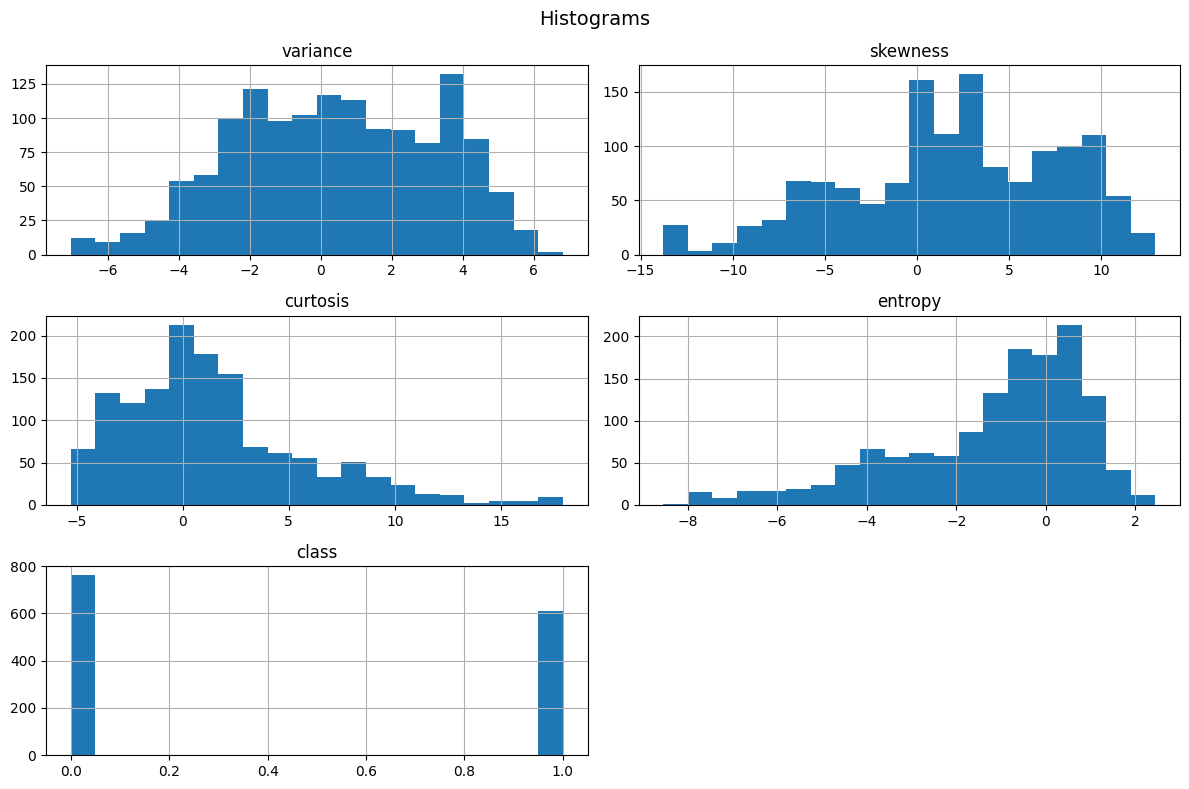

In [10]:
# Histograms
data.hist(figsize=(12, 8), bins=20)

plt.suptitle("Histograms", fontsize=14)
plt.tight_layout()
plt.show()

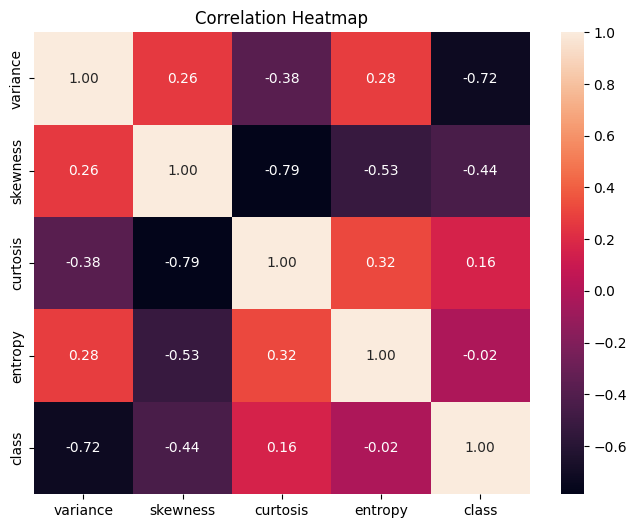

In [11]:
# Correlation Heatmap
plt.figure(figsize=(8,6))

sns.heatmap(data.corr(),annot=True,fmt=".2f")

plt.title("Correlation Heatmap")
plt.show()

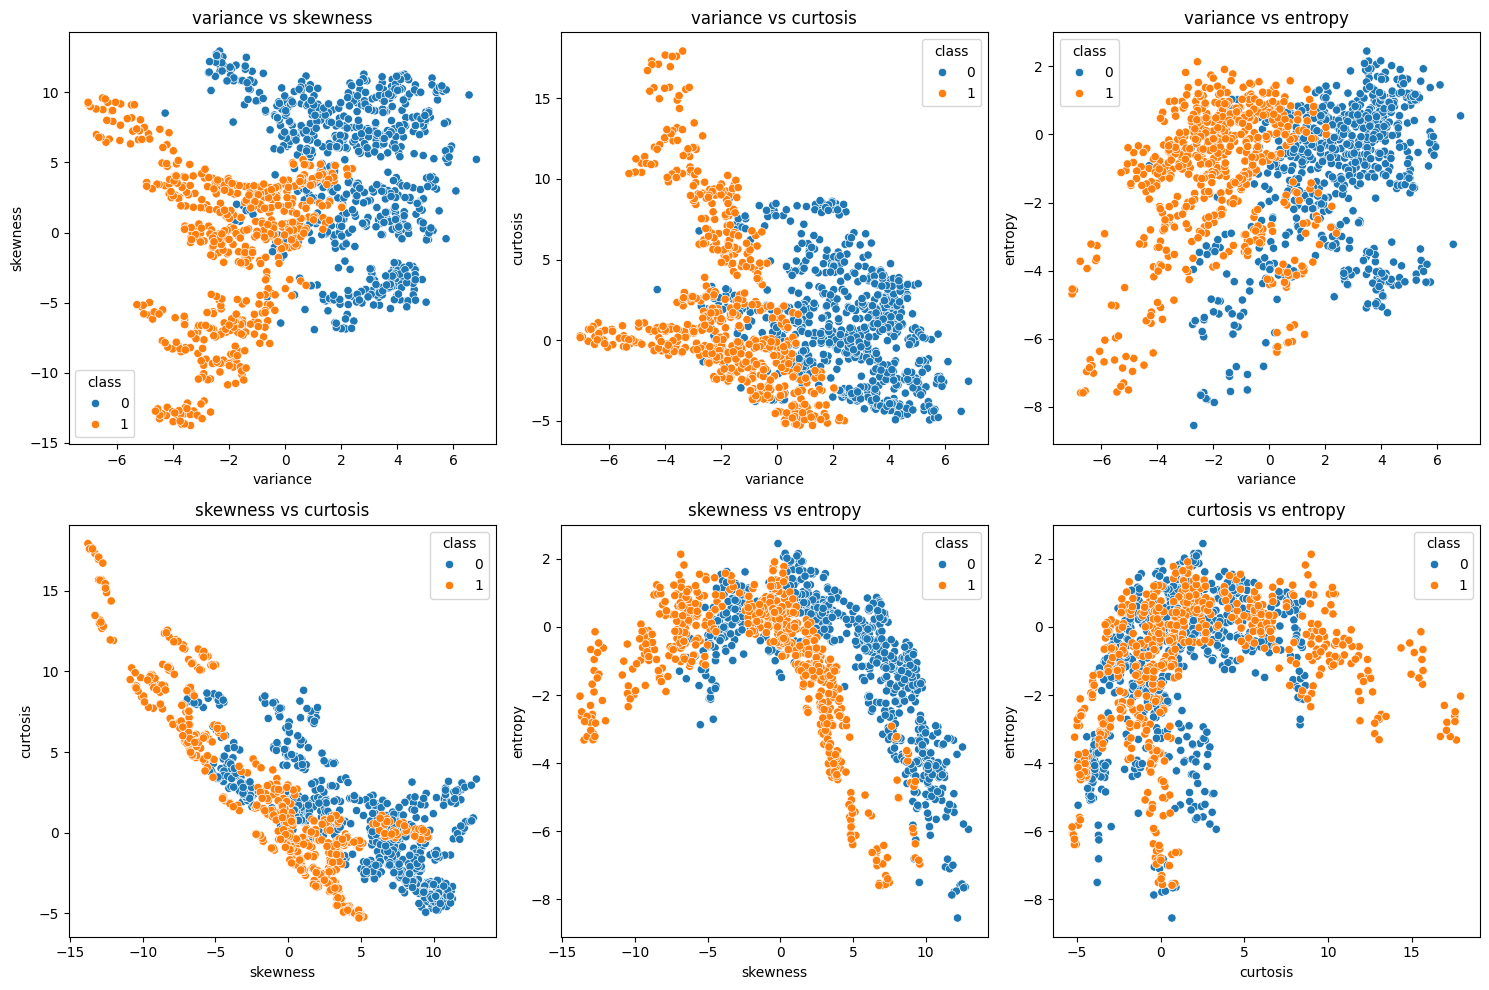

In [12]:
# Scatter Plot
plt.figure(figsize=(15,10))
features = data.columns.drop("class")
plot = 1
for i in range(len(features)):
  for j in range(i+1,len(features)):
    plt.subplot(2, 3, plot)
    sns.scatterplot(data=data,x=features[i],y=features[j],hue="class")
    plt.title(f"{features[i]} vs {features[j]}")
    plot += 1

plt.tight_layout()
plt.show()

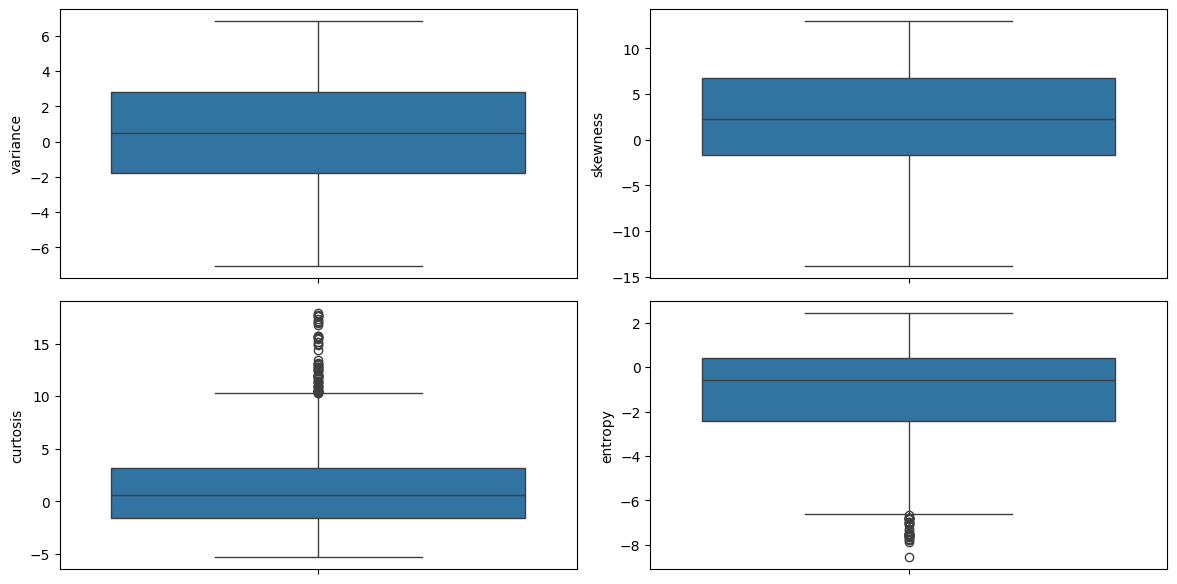

In [13]:
# Boxplots
plt.figure(figsize=(12,6))

for i, column in enumerate(data.columns.drop("class")):
    plt.subplot(2,2,i+1)
    sns.boxplot(y=data[column])

plt.tight_layout()
plt.show()

**TASK-3**

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

In [15]:
# Separate features and target
X = data.drop("class", axis=1)
y = data["class"].to_numpy()

In [16]:
# Normalize the features
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

In [17]:
# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(X_scaled,y,test_size=0.2,random_state=42,stratify=y)


**TASK-4**

In [18]:
import numpy as np

In [40]:
class Perceptron:

    def __init__(self, learning_rate=0.01, epochs=100):
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.error_history = []
        self.weight_history = []
        self.bias_history = []

    # Weight Initialization
    def initialize_parameters(self, n_features):
        self.weights = np.zeros(n_features)
        self.bias = 0

    # Step Activation Function
    def activation(self, z):
        if z >= 0:
            return 1
        return 0

    # Forward Propagation
    def predict(self, X):
        predictions = []

        for x in X:
            z = np.dot(x, self.weights) + self.bias
            y_pred = self.activation(z)
            predictions.append(y_pred)

        return np.array(predictions)

    # Training using Perceptron Learning Rule
    def fit(self, X, y):
      self.initialize_parameters(X.shape[1])
      for epoch in range(self.epochs):
          errors = 0
          for i in range(len(X)):
              z = np.dot(X[i], self.weights) + self.bias
              y_pred = self.activation(z)
              error = y[i] - y_pred
              if error != 0:
                  errors += 1

              # Update weights
              self.weights = self.weights + self.learning_rate * error * X[i]

              # Update bias
              self.bias = self.bias + self.learning_rate * error

          self.error_history.append(errors)
          self.weight_history.append(self.weights.copy())
          self.bias_history.append(self.bias)
          # Display epoch details
          print(f"Epoch {epoch+1} | Errors: {errors} | Weights: {self.weights} | Bias: {self.bias}")
          print("-"*50)

          # Stop if perfectly classified
          if errors == 0:
              print("Training Converged!")
              break

**TASK-5**

In [41]:
model = Perceptron(learning_rate=0.01,epochs=100)

In [42]:
model.fit(X_train, y_train)

Epoch 1 | Errors: 171 | Weights: [-0.06792364 -0.04617278 -0.05904233  0.02213631] | Bias: 0.07
--------------------------------------------------
Epoch 2 | Errors: 101 | Weights: [-0.08380509 -0.06774466 -0.08105979  0.00775587] | Bias: 0.09999999999999999
--------------------------------------------------
Epoch 3 | Errors: 43 | Weights: [-0.08780541 -0.07827122 -0.08945257  0.00240271] | Bias: 0.10999999999999999
--------------------------------------------------
Epoch 4 | Errors: 43 | Weights: [-0.09081985 -0.08978894 -0.09123274  0.00439111] | Bias: 0.11999999999999998
--------------------------------------------------
Epoch 5 | Errors: 57 | Weights: [-0.09878964 -0.09827279 -0.09836367  0.0110804 ] | Bias: 0.12999999999999998
--------------------------------------------------
Epoch 6 | Errors: 43 | Weights: [-0.0971687  -0.10179894 -0.10908865  0.0144443 ] | Bias: 0.13999999999999999
--------------------------------------------------
Epoch 7 | Errors: 30 | Weights: [-0.11075321 -0

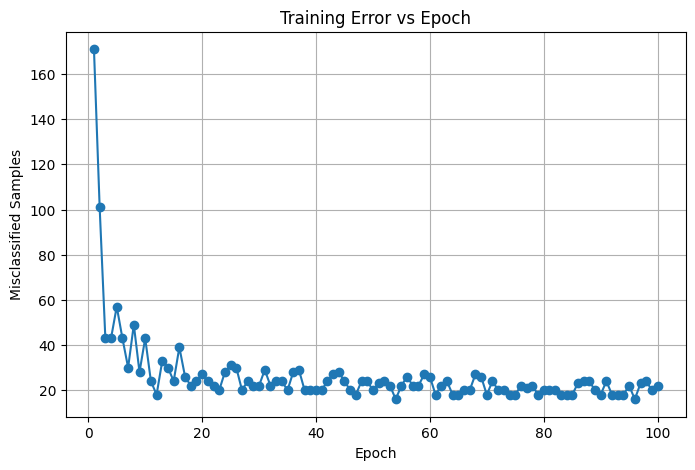

In [43]:
plt.figure(figsize=(8,5))

plt.plot(range(1, len(model.error_history)+1),
         model.error_history,
         marker='o')

plt.xlabel("Epoch")
plt.ylabel("Misclassified Samples")
plt.title("Training Error vs Epoch")
plt.grid(True)

plt.show()

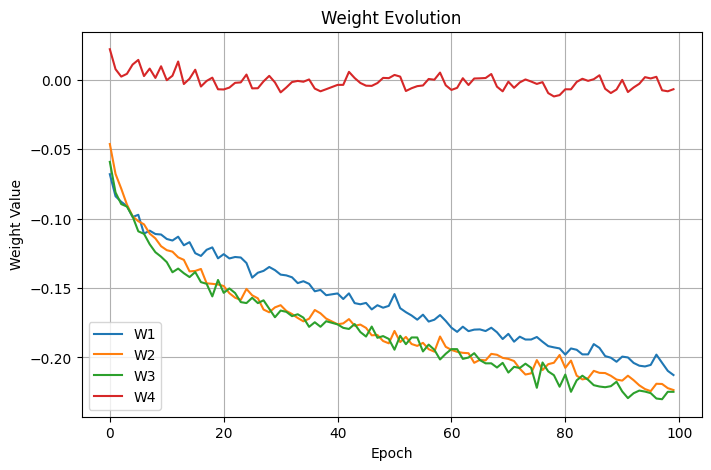

In [44]:
weights = np.array(model.weight_history)

plt.figure(figsize=(8,5))

for i in range(weights.shape[1]):
    plt.plot(weights[:, i], label=f"W{i+1}")

plt.xlabel("Epoch")
plt.ylabel("Weight Value")
plt.title("Weight Evolution")
plt.legend()
plt.grid(True)

plt.show()

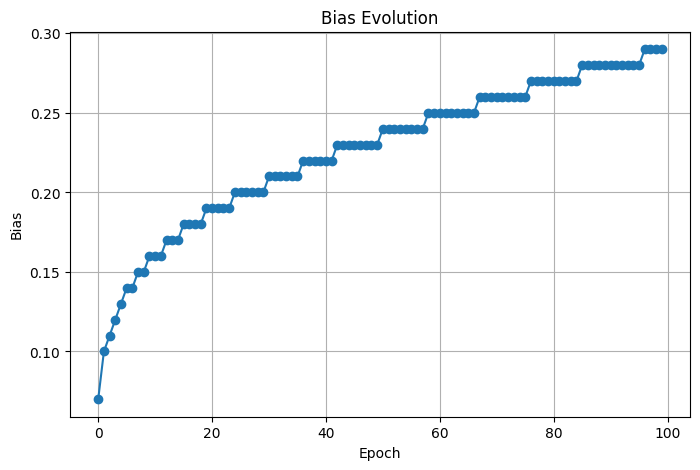

In [45]:
plt.figure(figsize=(8,5))

plt.plot(model.bias_history,
         marker='o')

plt.xlabel("Epoch")
plt.ylabel("Bias")
plt.title("Bias Evolution")
plt.grid(True)

plt.show()

**TASK-6**

In [22]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [23]:
y_pred = model.predict(X_test)

In [24]:
# Model Evaluation
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Accuracy : 0.9890909090909091
Precision: 0.9917355371900827
Recall   : 0.9836065573770492
F1 Score : 0.9876543209876543


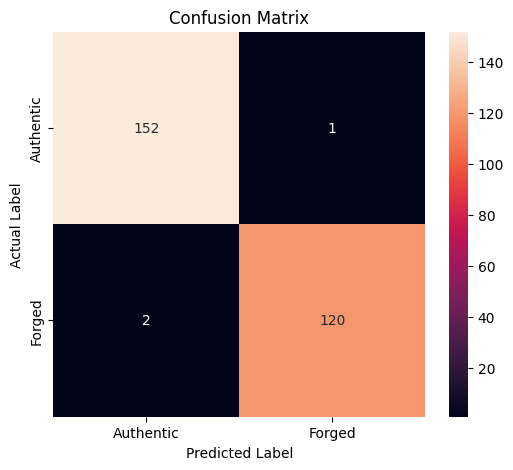

In [25]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm,annot=True,fmt='d',xticklabels=["Authentic", "Forged"],yticklabels=["Authentic", "Forged"])
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix")
plt.show()

**TASK-7**

In [51]:
class Perceptron:

    def __init__(self, learning_rate=0.01, epochs=100):
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.error_history = []

    # Weight Initialization
    def initialize_parameters(self, n_features):
        self.weights = np.zeros(n_features)
        self.bias = 0

    # Step Activation Function
    def activation(self, z):
        if z >= 0:
            return 1
        return 0

    # Forward Propagation
    def predict(self, X):
        predictions = []

        for x in X:
            z = np.dot(x, self.weights) + self.bias
            y_pred = self.activation(z)
            predictions.append(y_pred)

        return np.array(predictions)

    # Training using Perceptron Learning Rule
    def fit(self, X, y):
      self.initialize_parameters(X.shape[1])
      for epoch in range(self.epochs):
          errors = 0
          for i in range(len(X)):
              z = np.dot(X[i], self.weights) + self.bias
              y_pred = self.activation(z)
              error = y[i] - y_pred
              if error != 0:
                  errors += 1

              # Update weights
              self.weights = self.weights + self.learning_rate * error * X[i]

              # Update bias
              self.bias = self.bias + self.learning_rate * error

          self.error_history.append(errors)
          # Stop if perfectly classified
          if errors == 0:
              print("Training Converged!")
              break

In [52]:
learning_rates = [0.001, 0.01, 0.1]
results = []
for lr in learning_rates:
    model = Perceptron(learning_rate=lr, epochs=100)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    results.append([lr, accuracy])
print("Learning Rate\tAccuracy")
for lr, acc in results:
    print(f"{lr}\t\t{acc:.4f}")

Learning Rate	Accuracy
0.001		0.9891
0.01		0.9891
0.1		0.9891


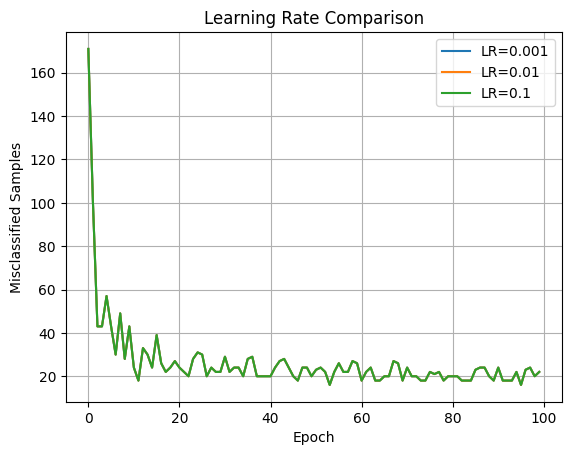

In [53]:
learning_rates = [0.001, 0.01, 0.1]

for lr in learning_rates:

    model = Perceptron(
        learning_rate=lr,
        epochs=100
    )

    model.fit(X_train, y_train)

    plt.plot(
        model.error_history,
        label=f"LR={lr}"
    )

plt.xlabel("Epoch")
plt.ylabel("Misclassified Samples")
plt.title("Learning Rate Comparison")
plt.legend()
plt.grid(True)

plt.show()

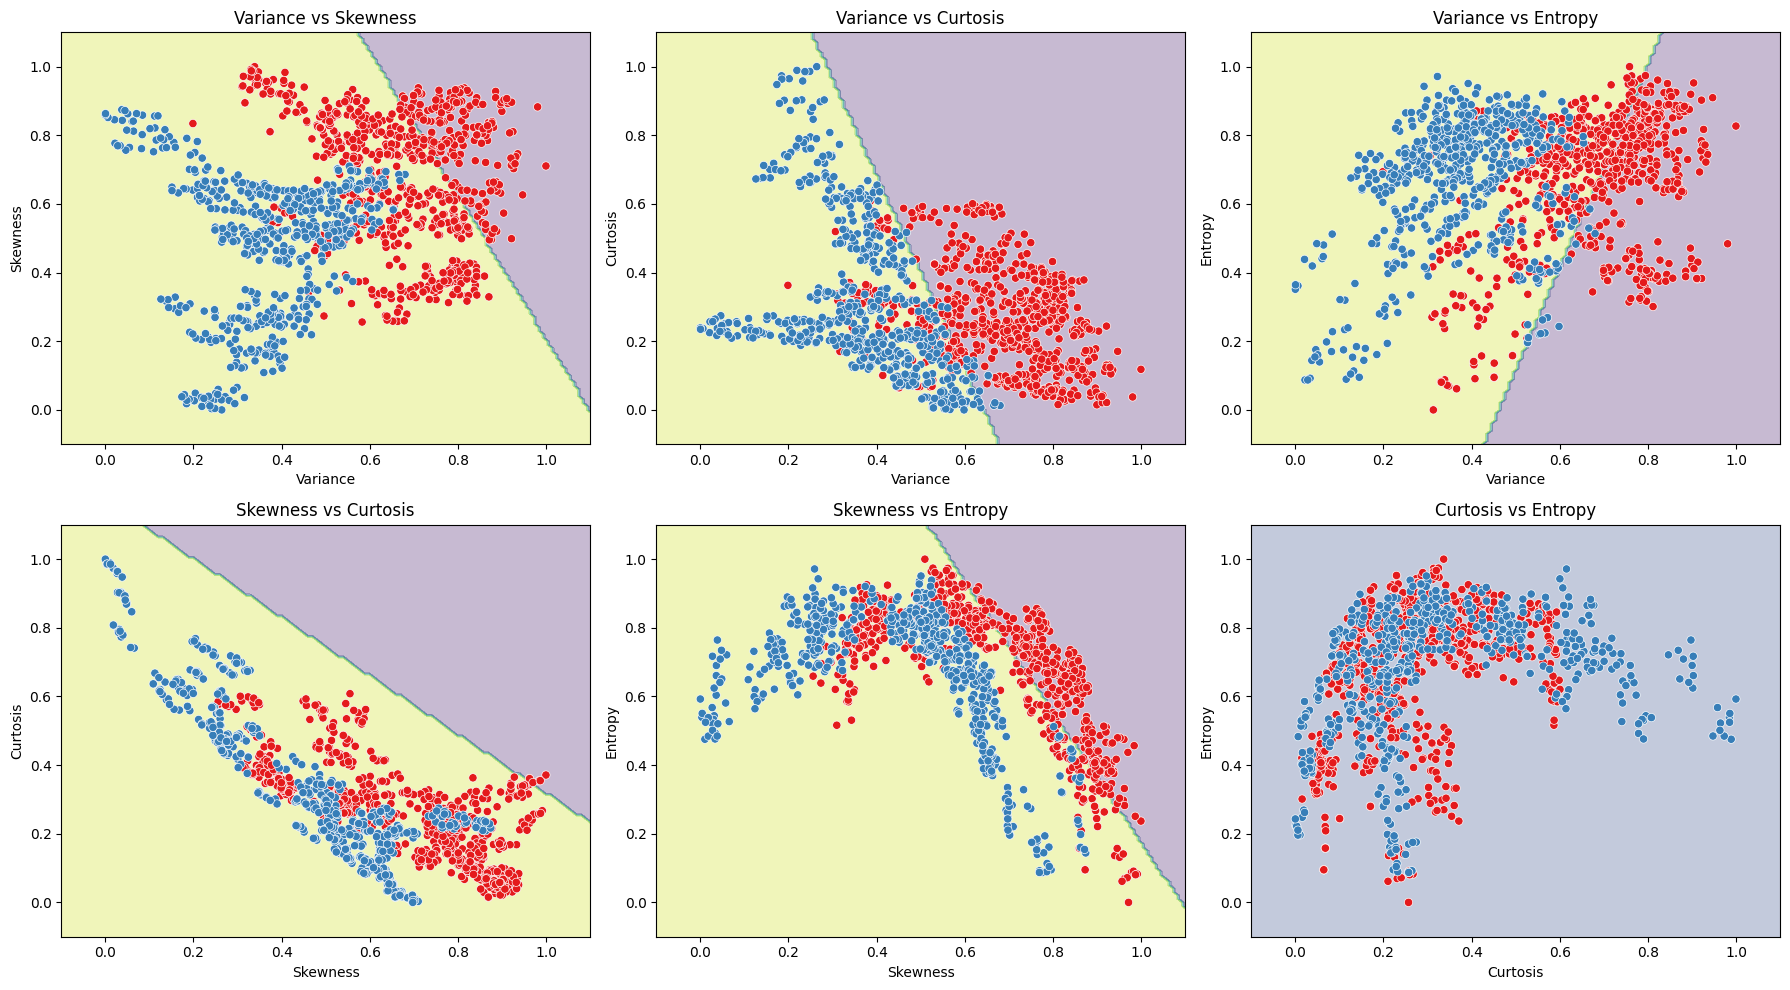

In [54]:
from itertools import combinations
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

feature_names = ["Variance", "Skewness", "Curtosis", "Entropy"]
pairs = list(combinations(range(4), 2))

plt.figure(figsize=(18,10))

plot = 1

for i, j in pairs:

    # Select two features
    X = data.iloc[:, [i, j]].values
    y = data["class"].values

    # Normalize
    scaler = MinMaxScaler()
    X = scaler.fit_transform(X)

    # Train-test split
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42
    )

    # Train your perceptron
    model = Perceptron(learning_rate=0.01, epochs=100)
    model.fit(X_train, y_train)

    # Mesh grid
    x_min, x_max = X[:,0].min()-0.1, X[:,0].max()+0.1
    y_min, y_max = X[:,1].min()-0.1, X[:,1].max()+0.1

    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, 0.01),
        np.arange(y_min, y_max, 0.01)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = model.predict(grid)
    Z = Z.reshape(xx.shape)

    # Plot
    plt.subplot(2,3,plot)

    plt.contourf(xx, yy, Z, alpha=0.3)

    sns.scatterplot(
        x=X[:,0],
        y=X[:,1],
        hue=y,
        palette="Set1",
        legend=False
    )

    plt.xlabel(feature_names[i])
    plt.ylabel(feature_names[j])
    plt.title(f"{feature_names[i]} vs {feature_names[j]}")

    plot += 1

plt.tight_layout()
plt.show()

**TASK-8**

In [29]:
from sklearn.linear_model import Perceptron

# Create the model
sk_model = Perceptron(max_iter=100,eta0=0.01,random_state=42)

# Train the model
sk_model.fit(X_train, y_train)

# Predict
y_pred = sk_model.predict(X_test)

Accuracy : 0.9709090909090909
Precision: 0.9384615384615385
Recall   : 1.0
F1 Score : 0.9682539682539683


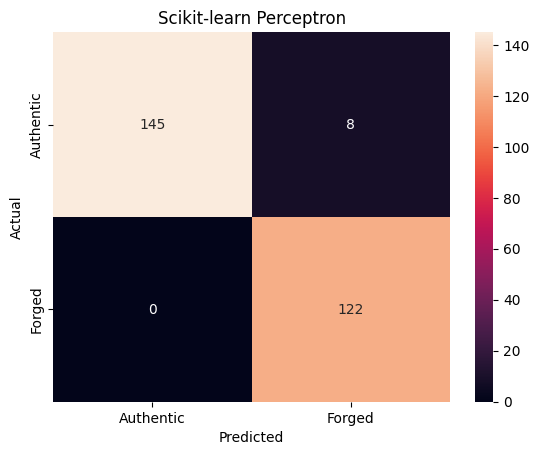

In [30]:
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm,annot=True,fmt="d",xticklabels=["Authentic","Forged"],yticklabels=["Authentic","Forged"])
plt.title("Scikit-learn Perceptron")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

**Additional**

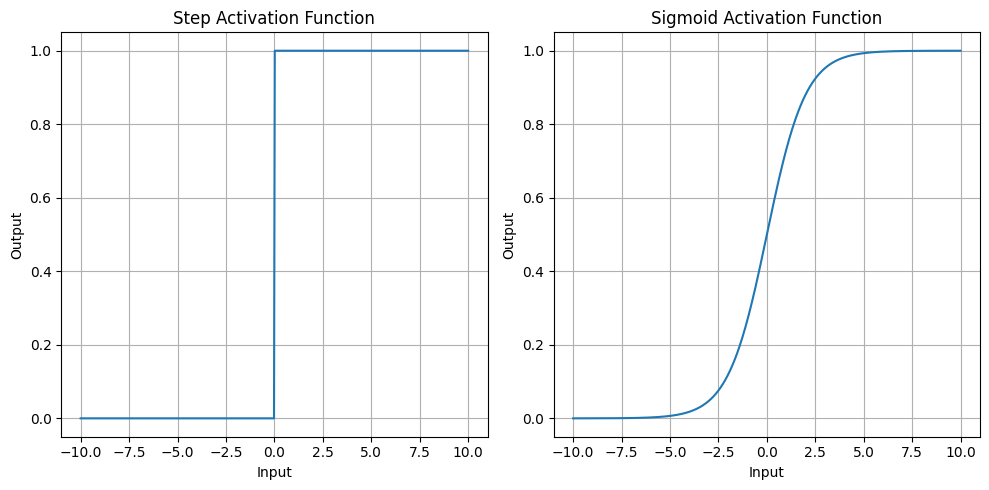

In [55]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-10, 10, 500)

# Step Function
step = np.where(x >= 0, 1, 0)

# Sigmoid Function
sigmoid = 1 / (1 + np.exp(-x))

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.plot(x, step)
plt.title("Step Activation Function")
plt.xlabel("Input")
plt.ylabel("Output")
plt.grid(True)

plt.subplot(1,2,2)
plt.plot(x, sigmoid)
plt.title("Sigmoid Activation Function")
plt.xlabel("Input")
plt.ylabel("Output")
plt.grid(True)

plt.tight_layout()
plt.show()

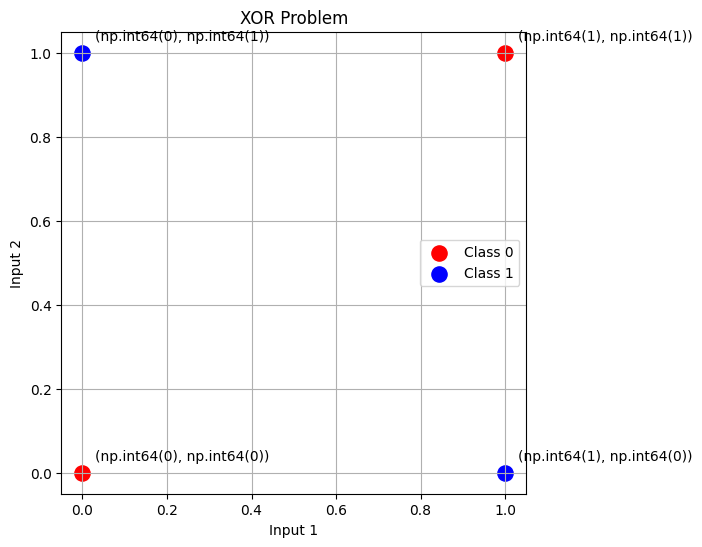

In [56]:
import matplotlib.pyplot as plt
import numpy as np

X = np.array([
    [0,0],
    [0,1],
    [1,0],
    [1,1]
])

y = np.array([0,1,1,0])

plt.figure(figsize=(6,6))

plt.scatter(
    X[y==0][:,0],
    X[y==0][:,1],
    color='red',
    s=120,
    label='Class 0'
)

plt.scatter(
    X[y==1][:,0],
    X[y==1][:,1],
    color='blue',
    s=120,
    label='Class 1'
)

plt.xlabel("Input 1")
plt.ylabel("Input 2")
plt.title("XOR Problem")

for i in range(len(X)):
    plt.text(X[i,0]+0.03, X[i,1]+0.03, str(tuple(X[i])))

plt.grid(True)
plt.legend()
plt.show()

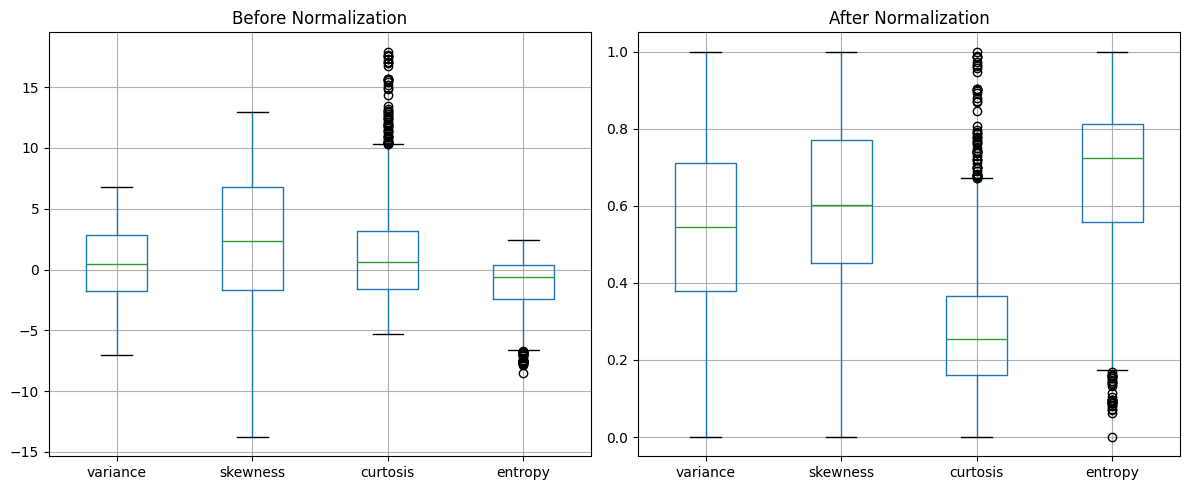

In [59]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
data.drop("class", axis=1).boxplot()
plt.title("Before Normalization")

normalized = pd.DataFrame(
    X_scaled,
    columns=data.columns[:-1]
)

plt.subplot(1,2,2)
normalized.boxplot()
plt.title("After Normalization")

plt.tight_layout()
plt.show()